# 03 — Dynamiques des prix
Objectif : comprendre la structure des prix, l'effet de la fenêtre de réservation et l'étendue des quantiles.

**Source :** PostgreSQL `hotel_features` (TABLESAMPLE BERNOULLI(30) pour les analyses ligne par ligne ; agrégations SQL pour les statistiques de segment).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import sys
sys.path.insert(0, "..")
from feature_engineering.config import POSTGRES_URI

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"savefig.dpi": 300, "figure.dpi": 120})

engine = create_engine(POSTGRES_URI)

FIGURES_DIR = Path("figures/03_price_dynamics")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    path = FIGURES_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"Enregistré → {path}")

In [2]:
# Sample for row-level analyses
df = pd.read_sql("""
    SELECT price_per_night, city_name, stars_int, boarding_canonical,
           nights, days_until_checkin, delta_vs_peer_medium_median_pct,
           hotel_name_normalized, room_base, source, check_in_month
    FROM hotel_features TABLESAMPLE BERNOULLI(30)
""", engine)
print(f"Échantillon : {len(df):,} lignes")
df.dtypes

Échantillon : 5,963,589 lignes


price_per_night                    float64
city_name                              str
stars_int                            int64
boarding_canonical                     str
nights                               int64
days_until_checkin                   int64
delta_vs_peer_medium_median_pct    float64
hotel_name_normalized                  str
room_base                              str
source                                 str
check_in_month                       int64
dtype: object

## 1. Distribution globale des prix

Enregistré → figures\03_price_dynamics\01_distribution_prix.png


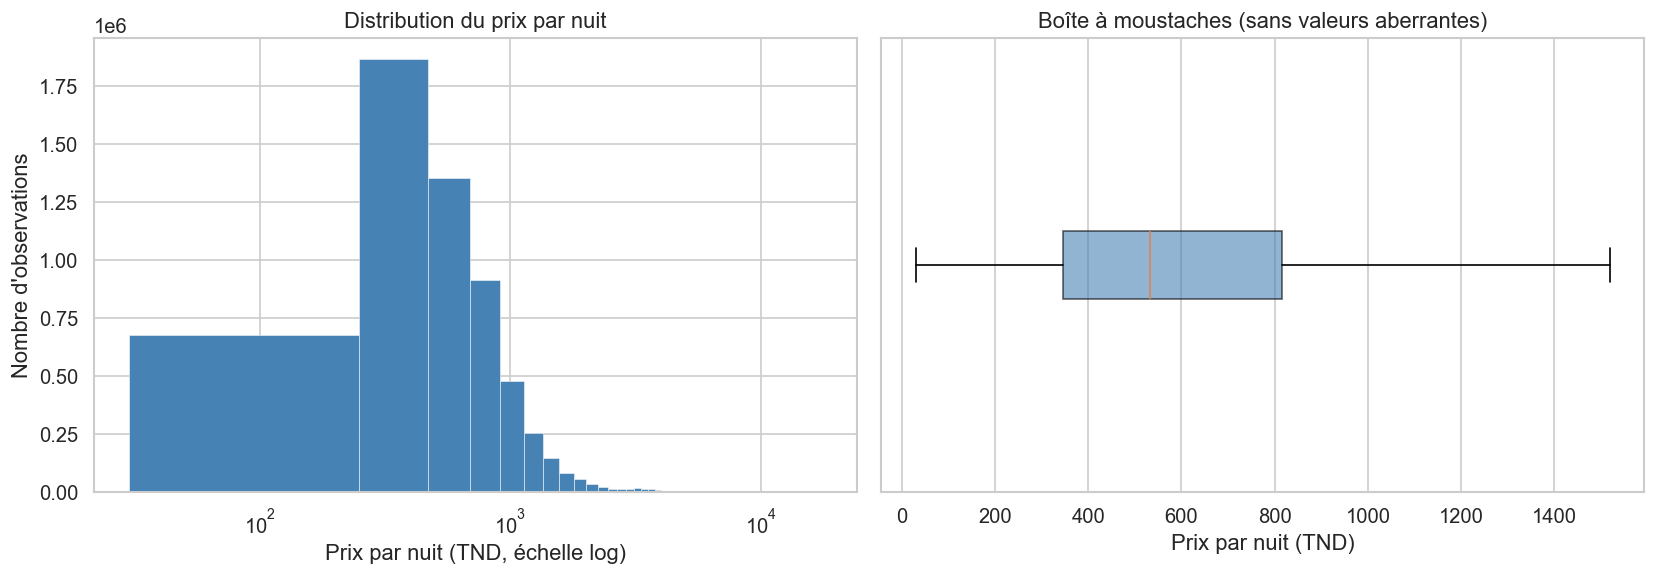

,count,mean,std,min,5%,25%,50%,75%,95%,max
prix_par_nuit,5963589.0,674.115105,605.543191,30.0,194.210007,345.679993,533.400024,815.0,1549.0,17613.619141


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ppn = df["price_per_night"].dropna()

# Histogramme échelle log
axes[0].hist(ppn, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Prix par nuit (TND, échelle log)")
axes[0].set_ylabel("Nombre d'observations")
axes[0].set_title("Distribution du prix par nuit")

# Boîte à moustaches
axes[1].boxplot(ppn, vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                showfliers=False)
axes[1].set_xlabel("Prix par nuit (TND)")
axes[1].set_title("Boîte à moustaches (sans valeurs aberrantes)")
axes[1].set_yticks([])

plt.tight_layout()
save_fig("01_distribution_prix")
plt.show()

ppn.describe(percentiles=[.05, .25, .5, .75, .95]).rename("prix_par_nuit").to_frame().T

## 2. Prix par segment (ville, étoiles, pension)

Enregistré → figures\03_price_dynamics\02a_prix_par_ville.png


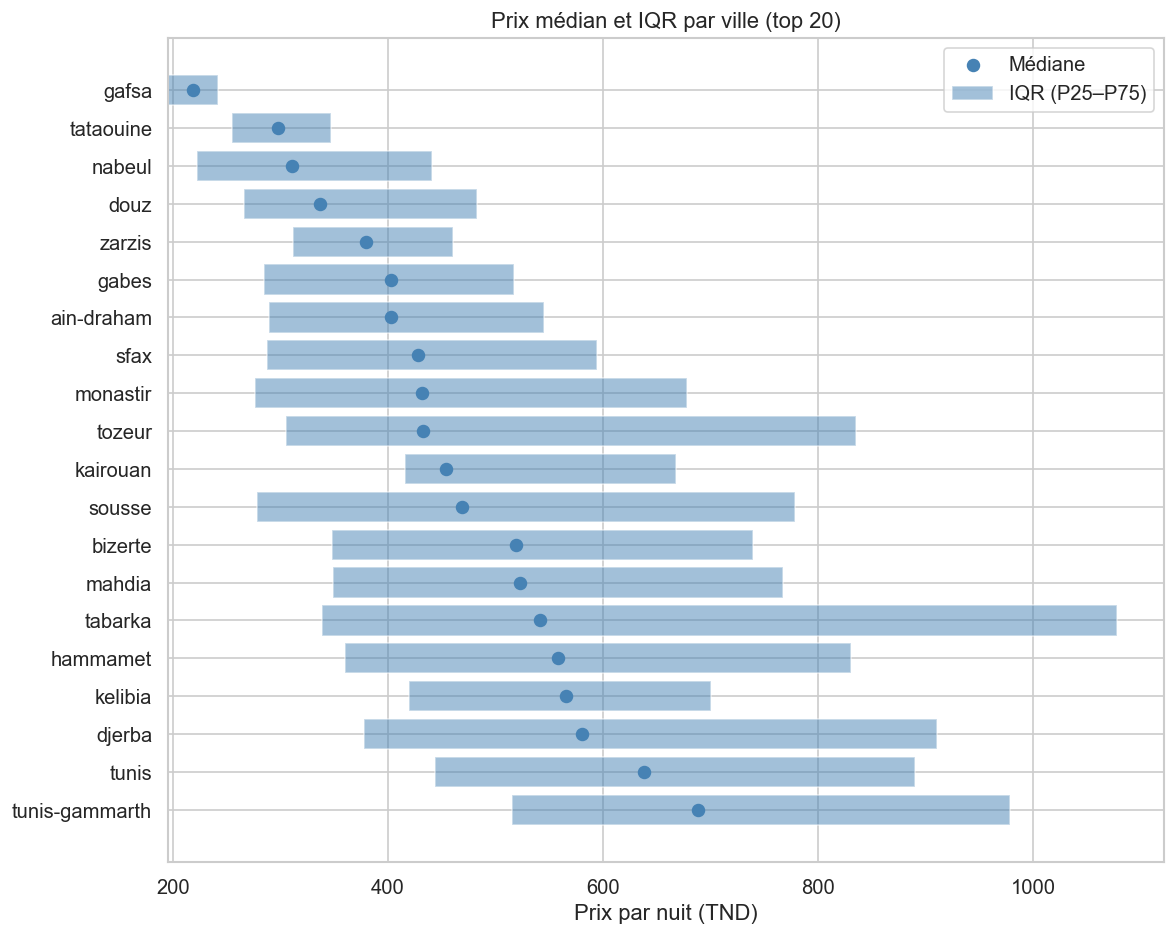

In [4]:
city_price_q = pd.read_sql("""
    SELECT city_name,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_per_night) AS p25,
           PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_per_night) AS p75,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY city_name
    HAVING COUNT(*) >= 500
    ORDER BY mediane DESC
    LIMIT 20
""", engine)

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(city_price_q))
ax.barh(y, city_price_q["p75"] - city_price_q["p25"],
        left=city_price_q["p25"], color="steelblue", alpha=0.5, label="IQR (P25–P75)")
ax.scatter(city_price_q["mediane"], y, color="steelblue", zorder=5, label="Médiane", s=50)
ax.set_yticks(list(y))
ax.set_yticklabels(city_price_q["city_name"])
ax.set_xlabel("Prix par nuit (TND)")
ax.set_title("Prix médian et IQR par ville (top 20)")
ax.legend()
plt.tight_layout()
save_fig("02a_prix_par_ville")
plt.show()

Enregistré → figures\03_price_dynamics\02b_prix_etoiles_pension.png


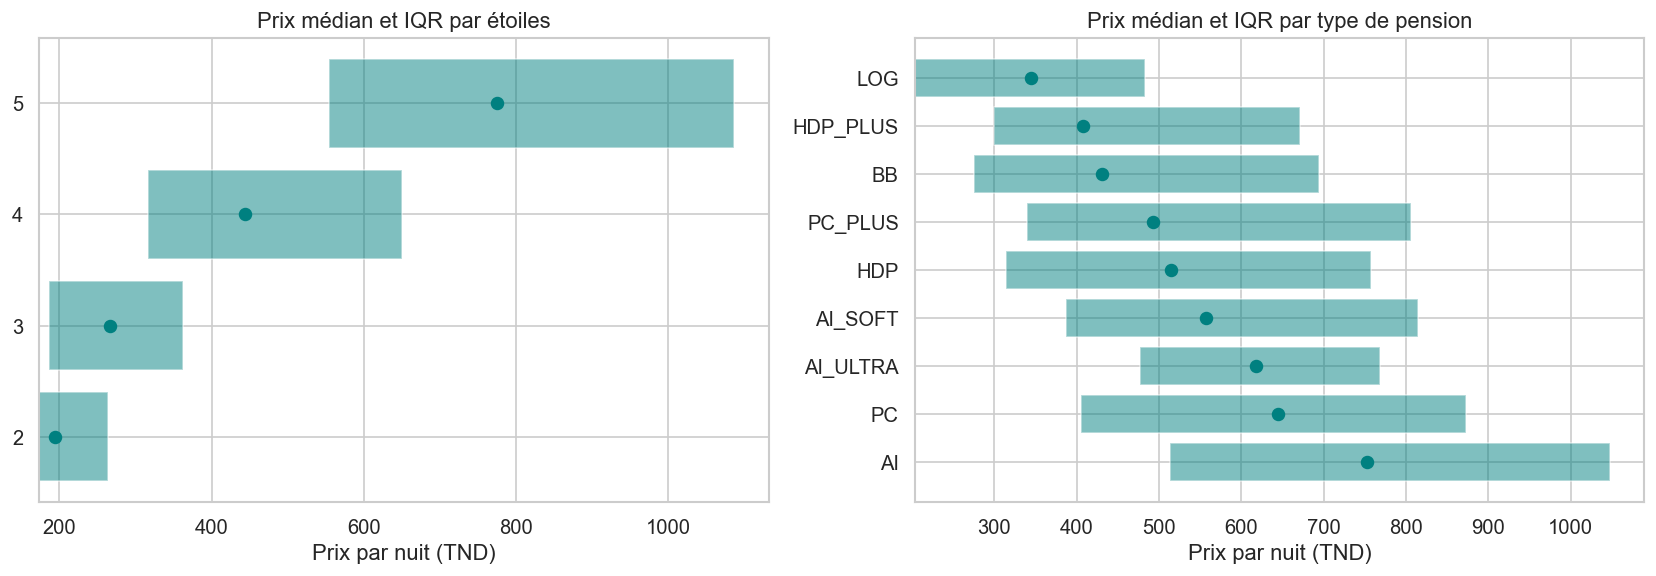

In [5]:
stars_price_q = pd.read_sql("""
    SELECT stars_int,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_per_night) AS p25,
           PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_per_night) AS p75,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY stars_int
    ORDER BY stars_int
""", engine)

board_price_q = pd.read_sql("""
    SELECT boarding_canonical,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_per_night) AS p25,
           PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_per_night) AS p75,
           COUNT(*) AS n
    FROM hotel_features
    WHERE boarding_canonical != 'UNKNOWN'
    GROUP BY boarding_canonical
    ORDER BY mediane DESC
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_seg, col, title in [
    (axes[0], stars_price_q, "stars_int", "Prix médian et IQR par étoiles"),
    (axes[1], board_price_q, "boarding_canonical", "Prix médian et IQR par type de pension"),
]:
    y = range(len(df_seg))
    ax.barh(y, df_seg["p75"] - df_seg["p25"], left=df_seg["p25"],
            color="teal", alpha=0.5)
    ax.scatter(df_seg["mediane"], y, color="teal", zorder=5, s=50)
    ax.set_yticks(list(y))
    ax.set_yticklabels(df_seg[col].astype(str))
    ax.set_xlabel("Prix par nuit (TND)")
    ax.set_title(title)

plt.tight_layout()
save_fig("02b_prix_etoiles_pension")
plt.show()

## 3. Décote multi-nuits

Enregistré → figures\03_price_dynamics\03_decote_multi_nuits.png


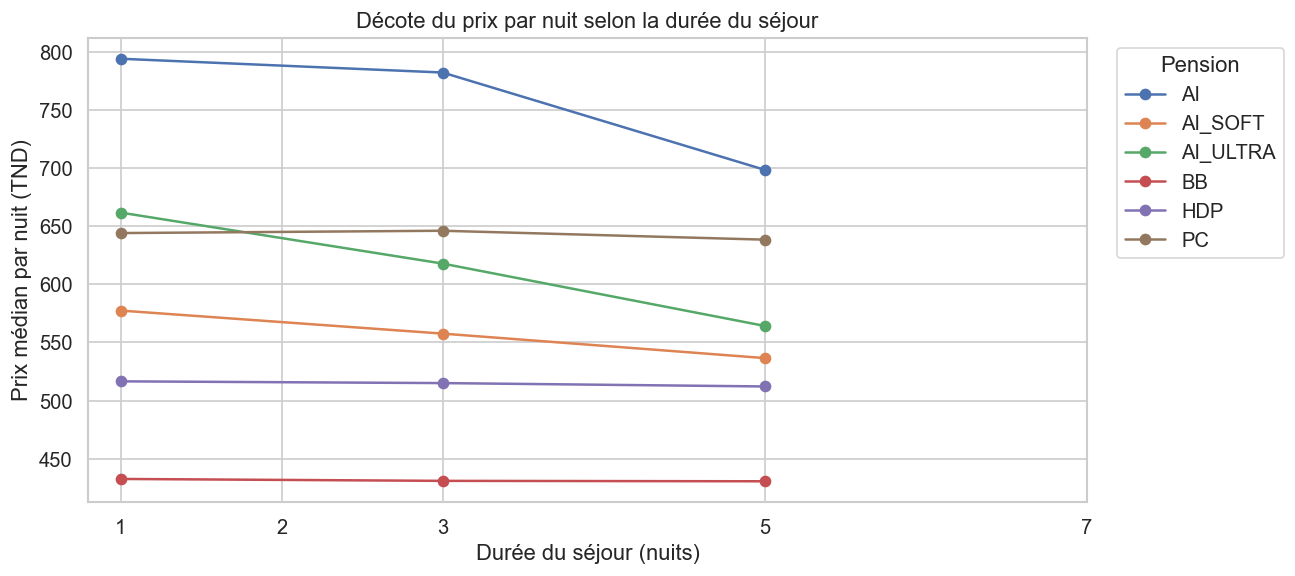

In [6]:
nights_q = pd.read_sql("""
    SELECT nights, boarding_canonical,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS mediane_ppn,
           COUNT(*) AS n
    FROM hotel_features
    WHERE boarding_canonical IN ('BB','HDP','AI','AI_SOFT','AI_ULTRA','PC')
    GROUP BY nights, boarding_canonical
    ORDER BY boarding_canonical, nights
""", engine)

fig, ax = plt.subplots(figsize=(11, 5))
for board, grp in nights_q.groupby("boarding_canonical"):
    ax.plot(grp["nights"], grp["mediane_ppn"], marker="o", label=board)

ax.set_xlabel("Durée du séjour (nuits)")
ax.set_ylabel("Prix médian par nuit (TND)")
ax.set_title("Décote du prix par nuit selon la durée du séjour")
ax.set_xticks([1, 2, 3, 5, 7])
ax.legend(title="Pension", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig("03_decote_multi_nuits")
plt.show()

## 4. Courbes de la fenêtre de réservation

Enregistré → figures\03_price_dynamics\04_courbes_fenetre_reservation.png


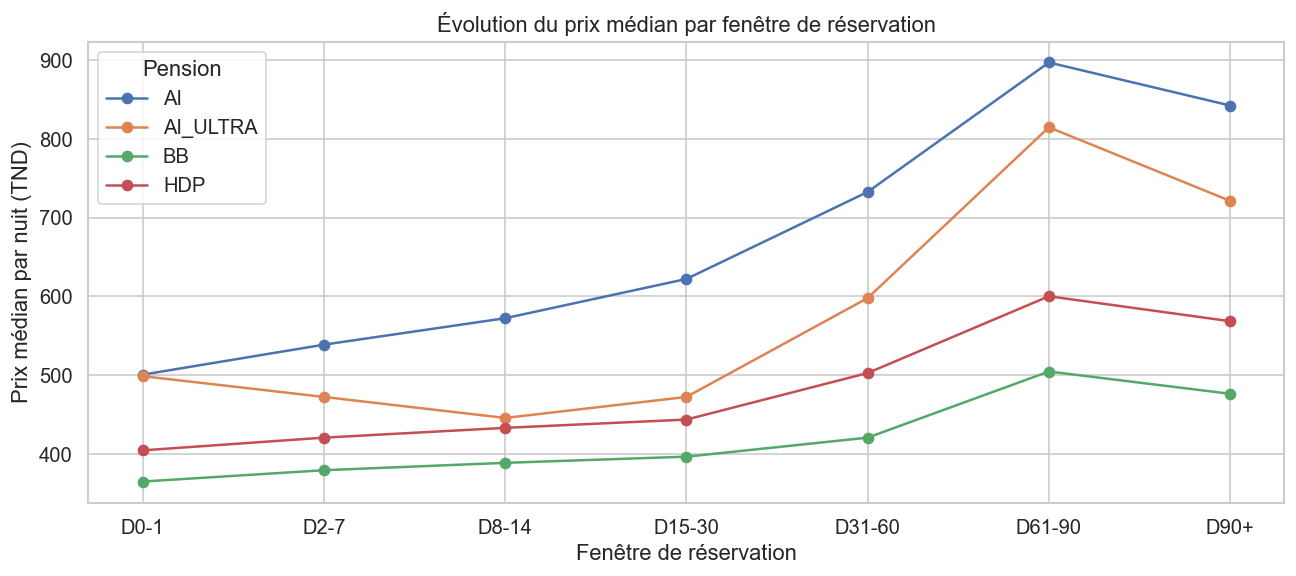

In [7]:
BUCKET_ORDER = ["D0-1", "D2-7", "D8-14", "D15-30", "D31-60", "D61-90", "D90+"]

window_q = pd.read_sql("""
    SELECT
        CASE
            WHEN days_until_checkin BETWEEN 0 AND 1   THEN 'D0-1'
            WHEN days_until_checkin BETWEEN 2 AND 7   THEN 'D2-7'
            WHEN days_until_checkin BETWEEN 8 AND 14  THEN 'D8-14'
            WHEN days_until_checkin BETWEEN 15 AND 30 THEN 'D15-30'
            WHEN days_until_checkin BETWEEN 31 AND 60 THEN 'D31-60'
            WHEN days_until_checkin BETWEEN 61 AND 90 THEN 'D61-90'
            ELSE 'D90+'
        END AS fenetre,
        boarding_canonical,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS mediane_ppn,
        COUNT(*) AS n
    FROM hotel_features
    WHERE boarding_canonical IN ('BB','HDP','AI','AI_ULTRA')
    GROUP BY fenetre, boarding_canonical
""", engine)

window_q["fenetre"] = pd.Categorical(window_q["fenetre"], categories=BUCKET_ORDER, ordered=True)
window_q = window_q.sort_values(["boarding_canonical", "fenetre"])

fig, ax = plt.subplots(figsize=(11, 5))
for board, grp in window_q.groupby("boarding_canonical"):
    grp = grp.sort_values("fenetre")
    ax.plot(grp["fenetre"].astype(str), grp["mediane_ppn"], marker="o", label=board)

ax.set_xlabel("Fenêtre de réservation")
ax.set_ylabel("Prix médian par nuit (TND)")
ax.set_title("Évolution du prix médian par fenêtre de réservation")
ax.legend(title="Pension")
plt.tight_layout()
save_fig("04_courbes_fenetre_reservation")
plt.show()

## 5. Étendue des quantiles (P10 / P50 / P90)

Enregistré → figures\03_price_dynamics\05_etendue_quantiles.png


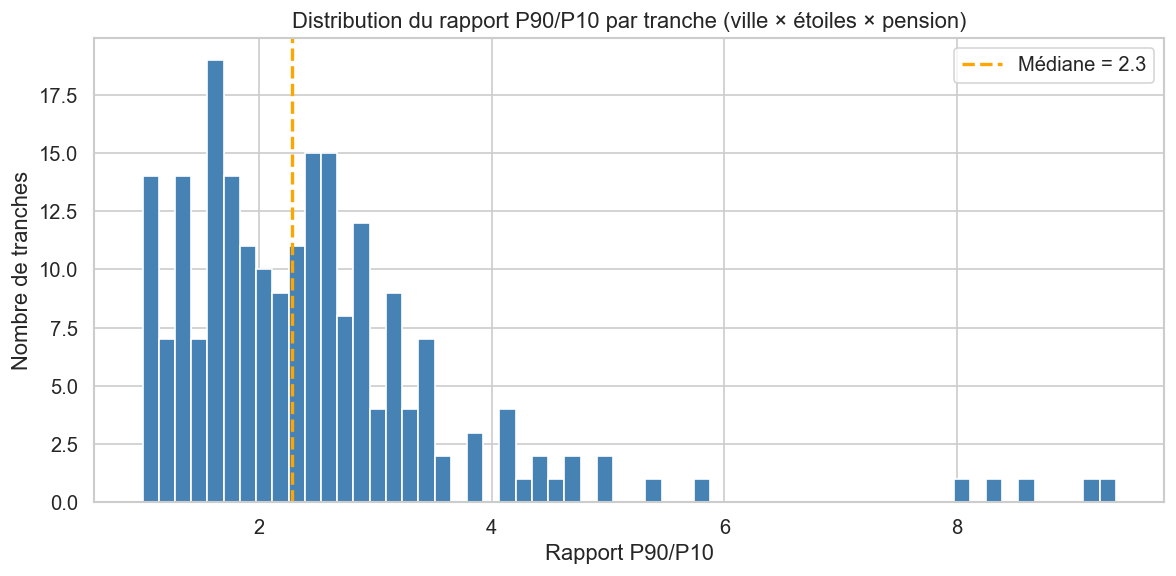

Rapport P90/P10 médian : 2.28
Rapport P90/P10 > 5 : 8 tranches sur 214


In [8]:
quantile_q = pd.read_sql("""
    SELECT city_name, stars_int, boarding_canonical,
           PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY price_per_night) AS p10,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS p50,
           PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY price_per_night) AS p90,
           COUNT(*) AS n
    FROM hotel_features
    WHERE boarding_canonical != 'UNKNOWN'
    GROUP BY city_name, stars_int, boarding_canonical
    HAVING COUNT(*) >= 50
""", engine)

quantile_q = quantile_q[quantile_q["p10"] > 0].copy()
quantile_q["spread_ratio"] = quantile_q["p90"] / quantile_q["p10"]
median_spread = quantile_q["spread_ratio"].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(quantile_q["spread_ratio"].clip(upper=20), bins=60, color="steelblue", edgecolor="white")
ax.axvline(median_spread, color="orange", linestyle="--", linewidth=2,
           label=f"Médiane = {median_spread:.1f}")
ax.set_xlabel("Rapport P90/P10")
ax.set_ylabel("Nombre de tranches")
ax.set_title("Distribution du rapport P90/P10 par tranche (ville × étoiles × pension)")
ax.legend()
plt.tight_layout()
save_fig("05_etendue_quantiles")
plt.show()

print(f"Rapport P90/P10 médian : {median_spread:.2f}")
print(f"Rapport P90/P10 > 5 : {(quantile_q['spread_ratio'] > 5).sum()} tranches sur {len(quantile_q)}")

## 6. Anatomie des valeurs aberrantes delta

Top 30 hôtels avec |delta médian pairs| > 500% :


,city_name,hotel_name_normalized,boarding_canonical,horizon,n,delta_moyen
0,tabarka,la cigale,BB,Long (D31+),25665,1102.677362
1,tabarka,la cigale,HDP,Long (D31+),25172,946.094384
2,tunis,four seasons hotels,LOG,Long (D31+),12161,854.547214
3,tunis,four seasons hotels,BB,Long (D31+),9404,671.777961
4,tabarka,la cigale,HDP,Moyen (D8-30),6603,883.752403
5,tabarka,la cigale,BB,Moyen (D8-30),6590,1032.081394
6,hammamet,la badira,BB,Long (D31+),4932,561.376789
7,hammamet,the orangers garden villas bungalows,AI,Long (D31+),4918,730.319946
8,tunis,four seasons hotels,LOG,Moyen (D8-30),3420,830.623302
9,tozeur,the mora ex anantara tozeur,HDP,Long (D31+),3109,690.656016


Enregistré → figures\03_price_dynamics\06_aberrants_delta_par_ville.png


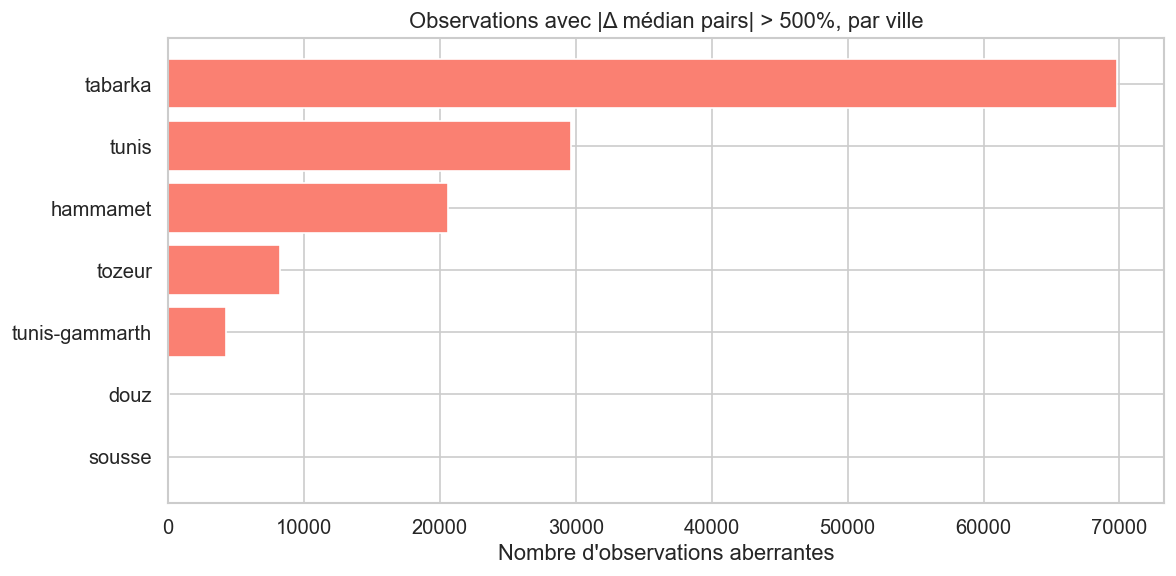

In [9]:
outlier_q = pd.read_sql("""
    SELECT city_name, hotel_name_normalized, boarding_canonical,
           CASE
               WHEN days_until_checkin BETWEEN 0 AND 7  THEN 'Court (D0-7)'
               WHEN days_until_checkin BETWEEN 8 AND 30 THEN 'Moyen (D8-30)'
               ELSE 'Long (D31+)'
           END AS horizon,
           COUNT(*) AS n,
           AVG(ABS(delta_vs_peer_medium_median_pct)) AS delta_moyen
    FROM hotel_features
    WHERE ABS(delta_vs_peer_medium_median_pct) > 500
    GROUP BY city_name, hotel_name_normalized, boarding_canonical, horizon
    ORDER BY n DESC
    LIMIT 30
""", engine)

print(f"Top 30 hôtels avec |delta médian pairs| > 500% :")
display(outlier_q.style.background_gradient(subset=["n", "delta_moyen"], cmap="Reds"))

# Aberrants par ville
outlier_city = pd.read_sql("""
    SELECT city_name, COUNT(*) AS n_aberrants
    FROM hotel_features
    WHERE ABS(delta_vs_peer_medium_median_pct) > 500
    GROUP BY city_name
    ORDER BY n_aberrants DESC
""", engine)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(outlier_city["city_name"][::-1], outlier_city["n_aberrants"][::-1], color="salmon")
ax.set_xlabel("Nombre d'observations aberrantes")
ax.set_title("Observations avec |Δ médian pairs| > 500%, par ville")
plt.tight_layout()
save_fig("06_aberrants_delta_par_ville")
plt.show()

## Conclusions pour la modélisation

- **Distribution des prix** : distribution fortement asymétrique à droite, compatible avec une hypothèse log-normale. La médiane et les percentiles extrêmes (P5, P95) sont à renseigner après exécution.

- **Décote multi-nuits** : le prix par nuit diminue avec la durée du séjour pour toutes les pensions — la variable `nights` doit être intégrée comme feature explicative, et non traitée comme une normalisation neutre.

- **Fenêtre de réservation** : l'effet est non linéaire et varie selon le type de pension. Une possible inversion de prix (last-minute moins cher qu'en avance) est à confirmer par boarding. `days_until_checkin` doit être traité comme feature non linéaire (avec ses buckets).

- **Étendue des quantiles** : le rapport P90/P10 médian est significatif (> 1), justifiant des sorties probabilistes (intervalles P10/P50/P90) plutôt qu'un point unique → **confirme la décision D2**.

- **Valeurs aberrantes delta** : les ~12 000 lignes avec |Δ médian pairs| > 500% sont concentrées dans certaines villes et proviennent majoritairement d'hôtels avec peu de pairs dans leur granularité medium → à surveiller pour la détection d'anomalies (**décision D3**). Ces hôtels isolés peuvent nécessiter un traitement spécifique (fallback sur la granularité *loose* ou exclusion du training set).